## ⚙️ Configuration & Imports

> Import `libraries`, setup `configurations`, and set output `designs`

In [45]:
import os
import warnings
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

import cv2
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image

In [36]:
Root                = "Dataset"  
Classes             = ['car', 'heavy_vehicle', 'motorcycle']
Splits              = ["train", "val", "test"]      
CameraKeyword       = "cam"                        
OutputDirectory     = "EDA Results"

In [37]:
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

CLASS_COLORS = {
    "car":           "#4A90D9",
    "motorcycle":    "#E8874A",
    "heavy_vehicle": "#5CB85C",
    "neutral":       "#9E9E9E",
}
SPLIT_COLORS = {"train": "#4A90D9", "val": "#E8874A", "test": "#5CB85C", "N/A": "#9E9E9E"}


In [38]:
os.makedirs(OutputDirectory, exist_ok=True)
print("✓ Config loaded.")
print(f"  Root                 : {Root}")
print(f"  Classes              : {Classes}")
print(f"  Splits               : {Splits}")
print(f"  Camera Keyword       : {CameraKeyword}")
print(f"  Output Directory     : {OutputDirectory}")

✓ Config loaded.
  Root                 : Dataset
  Classes              : ['car', 'heavy_vehicle', 'motorcycle']
  Splits               : ['train', 'val', 'test']
  Camera Keyword       : cam
  Output Directory     : EDA Results


## 📂 Load Dataset

Parses every `.txt` label file across all locations and returns a single
`DataFrame` (`data`) with **one row per bounding-box annotation**.

| Column | Description |
|--------|-------------|
| `location` | specific location |
| `stem` | filename without extension |
| `img_path` | absolute path to the image file |
| `img_w/h` | native image pixel dimensions |
| `camera` | camera ID extracted from filename |
| `class_id/name` | integer ID and string name |
| `cx cy bw bh` | YOLO normalised box coordinates |
| `area` | `bw × bh` (normalised) |
| `aspect_ratio` | `bw / bh` |
| `valid` | False if any format error detected |
| `issue` | string description of the issue |


In [ ]:
def load_dataset_by_location(root, Classes):
    root = Path(root)
    records = []

    for location_dir in root.iterdir():
        if not location_dir.is_dir():
            continue
            
        location_name = location_dir.name
        
        img_dir = location_dir / "images"
        lbl_dir = location_dir / "labels"

        if not lbl_dir.exists() or not img_dir.exists():
            print(f"  [SKIP] Folder '{location_name}' does not contain both 'images' and 'labels'.")
            continue

        lbl_files = list(lbl_dir.glob("*.txt"))
        print(f"  Location '{location_name}': {len(lbl_files)} label files")

        for lbl_path in lbl_files:
            stem = lbl_path.stem

            img_path = None
            for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                c = img_dir / (stem + ext)
                if c.exists():
                    img_path = c
                    break

            img_w = img_h = None
            if img_path:
                try:
                    with Image.open(img_path) as im:
                        img_w, img_h = im.size
                except Exception:
                    pass

            camera_id = None
            if 'CAMERA_KEYWORD' in globals() and CameraKeyword:
                m = re.search(rf"({re.escape(CameraKeyword)}\w*)", stem, re.IGNORECASE)
                camera_id = m.group(1).lower() if m else "unknown"

            with open(lbl_path, encoding='utf-8') as f:
                lines = f.readlines()

            if not any(l.strip() for l in lines):
                records.append({
                    "location": location_name, "stem": stem,
                    "img_path": str(img_path) if img_path else None,
                    "img_w": img_w, "img_h": img_h, "camera": camera_id,
                    "class_id": None, "class_name": None,
                    "cx": None, "cy": None, "bw": None, "bh": None,
                    "area": None, "aspect_ratio": None,
                    "valid": True, "issue": "empty_label",
                })
                continue

            for line in lines:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                issue = None
                valid_flag = True

                if len(parts) != 5:
                    records.append({
                        "location": location_name, "stem": stem,
                        "img_path": str(img_path) if img_path else None,
                        "img_w": img_w, "img_h": img_h, "camera": camera_id,
                        "class_id": None, "class_name": None,
                        "cx": None, "cy": None, "bw": None, "bh": None,
                        "area": None, "aspect_ratio": None,
                        "valid": False, "issue": "wrong_field_count",
                    })
                    continue

                try:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                except ValueError:
                    records.append({
                        "location": location_name, "stem": stem,
                        "img_path": str(img_path) if img_path else None,
                        "img_w": img_w, "img_h": img_h, "camera": camera_id,
                        "class_id": None, "class_name": None,
                        "cx": None, "cy": None, "bw": None, "bh": None,
                        "area": None, "aspect_ratio": None,
                        "valid": False, "issue": "parse_error",
                    })
                    continue

                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                    issue = "out_of_range"; valid_flag = False
                if cx-bw/2 < 0 or cy-bh/2 < 0 or cx+bw/2 > 1 or cy+bh/2 > 1:
                    issue = (issue+"|overflow") if issue else "overflow"; valid_flag = False
                if cls_id >= len(Classes):
                    issue = (issue+"|unknown_class") if issue else "unknown_class"; valid_flag = False

                cls_name = Classes[cls_id] if cls_id < len(Classes) else f"class_{cls_id}"

                records.append({
                    "location": location_name, "stem": stem,
                    "img_path": str(img_path) if img_path else None,
                    "img_w": img_w, "img_h": img_h, "camera": camera_id,
                    "class_id": cls_id, "class_name": cls_name,
                    "cx": cx, "cy": cy, "bw": bw, "bh": bh,
                    "area": bw * bh, "aspect_ratio": bw / bh if bh > 0 else np.nan,
                    "valid": valid_flag, "issue": issue,
                })

    return pd.DataFrame(records)

print("Loading dataset …")
data = load_dataset_by_location(Root, Classes)
print(f"\n✓ Loaded {len(data)} annotation rows across {data['stem'].nunique()} images.")
data.head(10)

Loading dataset …
  Location 'Location A': 182 label files
  Location 'Location B': 966 label files
  Location 'Location C': 1092 label files
  Location 'Location D': 838 label files
  Location 'Location E': 200 label files
  Location 'Location F': 391 label files

✓ Loaded 43772 annotation rows across 3669 images.


,location,stem,img_path,img_w,img_h,camera,class_id,class_name,cx,cy,bw,bh,area,aspect_ratio,valid,issue
0,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.561180,0.818838,0.063975,0.198204,0.012680,0.322774,True,None
1,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.409938,0.573020,0.044720,0.164986,0.007378,0.271057,True,None
2,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.467391,0.538694,0.041615,0.131767,0.005483,0.315822,True,None
3,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.473292,0.795585,0.062112,0.211492,0.013136,0.293685,True,None
4,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.318012,0.728594,0.067081,0.181595,0.012182,0.369398,True,None
5,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.545342,0.649423,0.050932,0.151698,0.007726,0.335744,True,None
6,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.050932,0.659942,0.055901,0.148376,0.008294,0.376749,True,None
7,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.396894,0.430180,0.048447,0.114050,0.005525,0.424788,True,None
8,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.364907,0.489974,0.039130,0.125123,0.004896,0.312735,True,None
9,Location A,frame0_jpg.rf.7f2e207aa9cfdbccdbf8284fe45a7779,Dataset\Location A\images\frame0_jpg.rf.7f2e20...,640,359,unknown,2.0,motorcycle,0.362422,0.217028,0.022981,0.081939,0.001883,0.280469,True,None


## 🌲 EDA 01 - Dataset Structure & Integrity Audit

Allows diagnosis of the dataset balance based on the number of annotations and images per location. This EDA also uncover the number of annotation issues which are empty label and wrong field

Per-location summary:
  location  total_files  total_annotations  empty_labels  invalid_annotations
Location A          182               5292             0                    0
Location B          966              12240             5                    0
Location C         1092               3375             4                    0
Location D          838              19345             1                    0
Location E          200               1153             0                    0
Location F          391               2354             2                    1


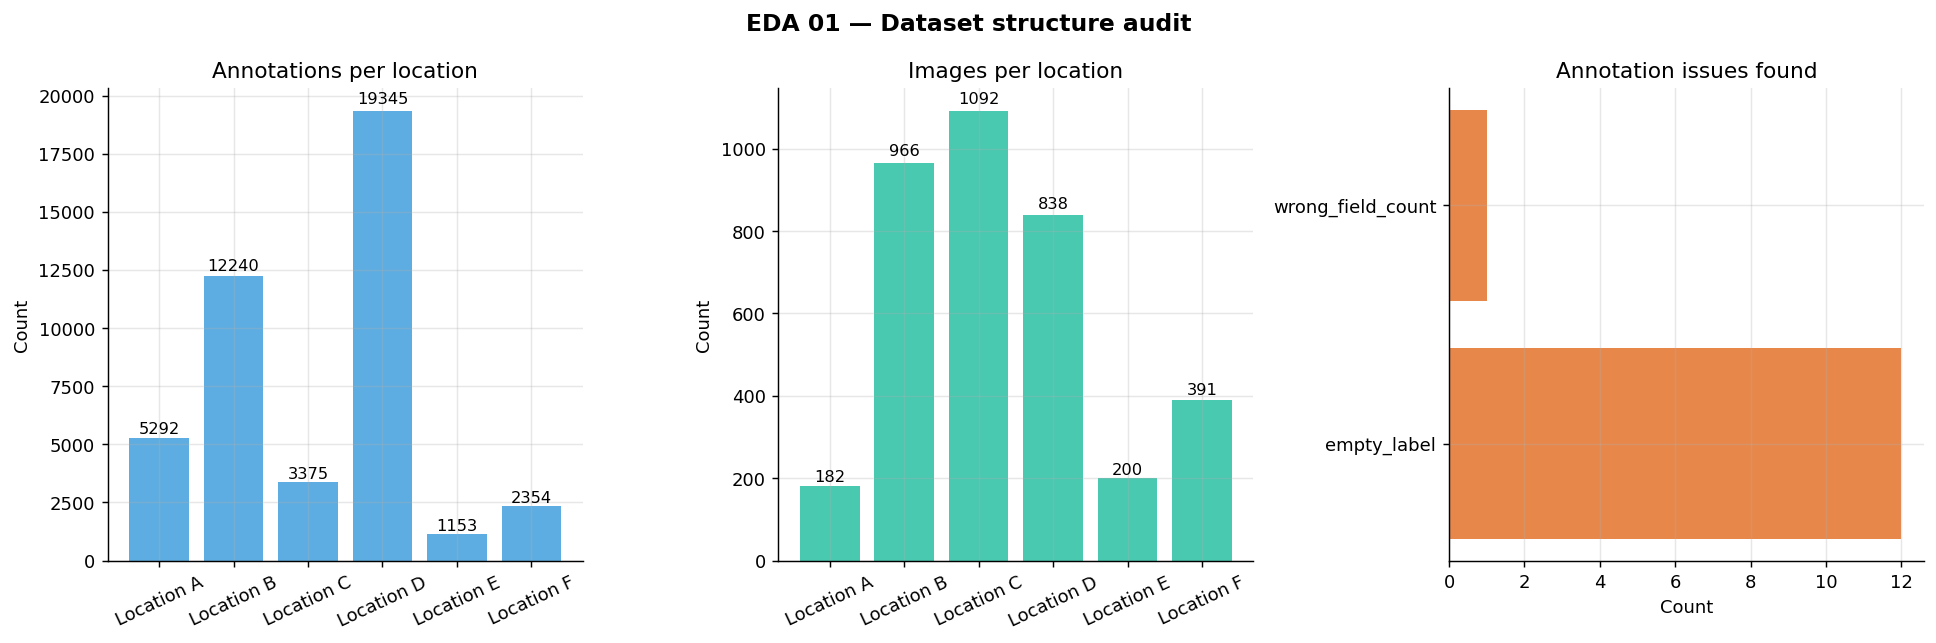

✓ Saved → EDA Results/1. Structure Audit.png


In [44]:
LocationSummary = data.groupby("location").agg(
    total_files        = ("stem",     "nunique"),
    total_annotations  = ("class_id", "count"),
    empty_labels       = ("issue",    lambda x: (x == "empty_label").sum()),
    invalid_annotations= ("valid",    lambda x: (~x).sum()),
).reset_index()

print("Per-location summary:")
print(LocationSummary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("EDA 01 — Dataset structure audit", fontweight="bold", fontsize=13)

ax = axes[0]
bars = ax.bar(LocationSummary["location"], LocationSummary["total_annotations"], color="#5DADE2")
ax.set_title("Annotations per location"); ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=25)
for bar, v in zip(bars, LocationSummary["total_annotations"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(v*0.01), str(v),
            ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(LocationSummary["location"], LocationSummary["total_files"], color="#48C9B0")
ax.set_title("Images per location"); ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=25)
for bar, v in zip(bars, LocationSummary["total_files"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(v*0.01), str(v),
            ha="center", va="bottom", fontsize=9)

ax = axes[2]
issue_counts = data["issue"].value_counts().dropna()
if len(issue_counts):
    ax.barh(issue_counts.index, issue_counts.values, color="#E8874A")
    ax.set_title("Annotation issues found"); ax.set_xlabel("Count")
else:
    ax.text(0.5, 0.5, "No issues found ✓", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="green")
    ax.set_title("Annotation issues")

plt.tight_layout()
plt.savefig(f"{OutputDirectory}/1. Structure Audit.png", bbox_inches="tight")
plt.show()
print(f"✓ Saved → {OutputDirectory}/1. Structure Audit.png")

## 🥧 EDA 02 - Class Distribution & Imbalance

Counts how many bounding boxes (classes) that existed. This is useful to uncover class imbalance as it's the most common problem in Machine Learning. Model could achieve high accuracy on severely imbalanced data by ignoring minority classes

Global class counts:
  motorcycle              23854  (54.5%)
  car                     14739  (33.7%)
  heavy_vehicle            5166  (11.8%)


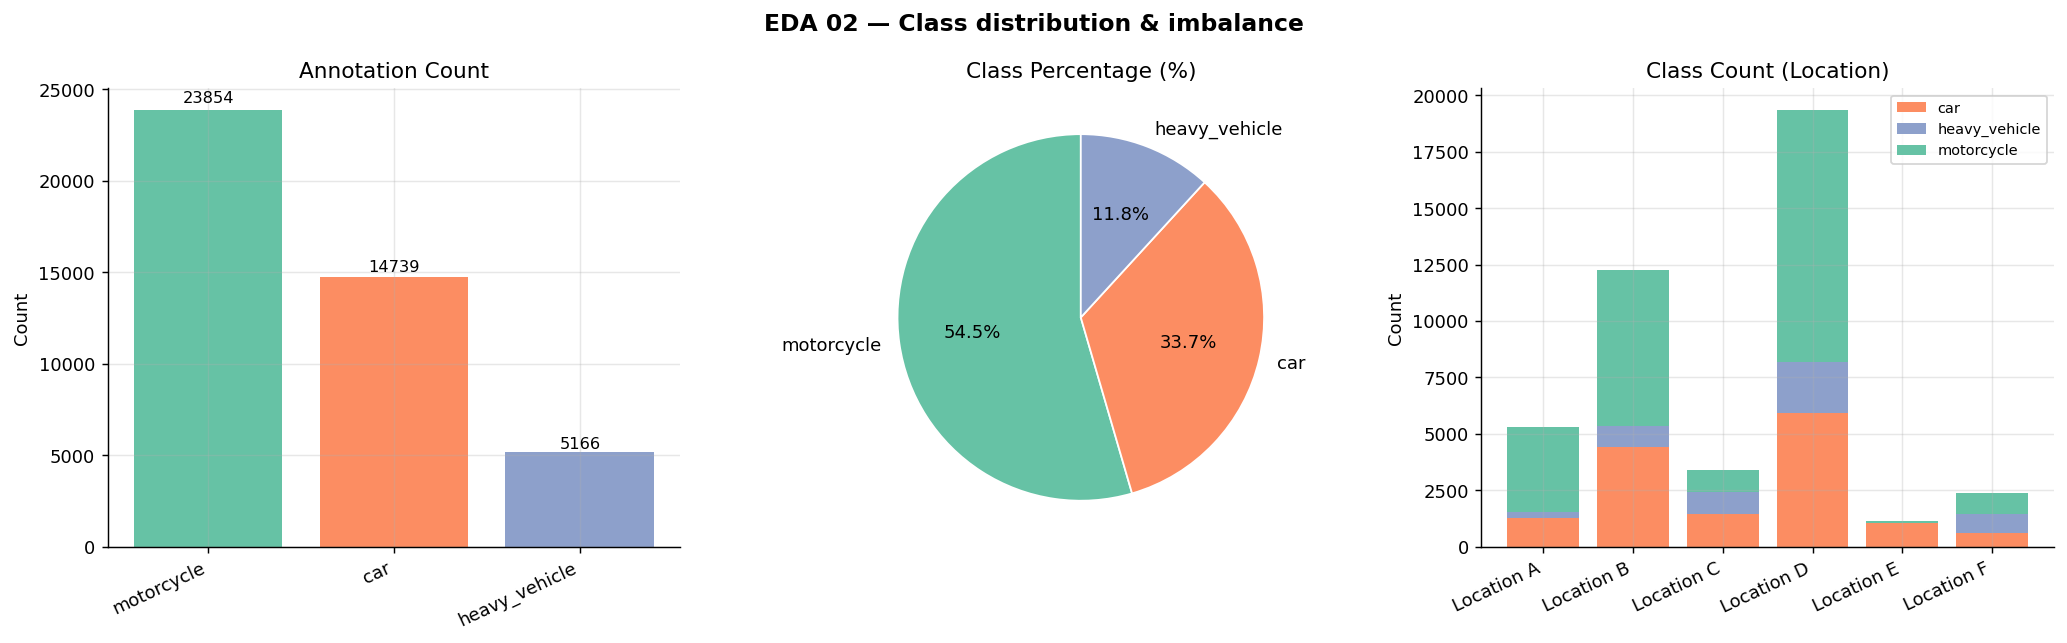

✓ Saved → EDA Results/2. Class Distribution.png


In [48]:
valid = data[data["class_name"].notna()]
global_counts = valid["class_name"].value_counts()

print("Global class counts:")
for cls, cnt in global_counts.items():
    print(f"  {cls:<22} {cnt:>6}  ({cnt/global_counts.sum()*100:.1f}%)")

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle("EDA 02 — Class distribution & imbalance", fontweight="bold", fontsize=13)

cmap = plt.get_cmap("Set2")
colors = [cmap(i % 8) for i in range(len(global_counts))]
color_dict = dict(zip(global_counts.index, colors))

ax = fig.add_subplot(gs[0])
bars = ax.bar(global_counts.index, global_counts.values, color=colors)
ax.set_title("Annotation Count"); ax.set_ylabel("Count")
ax.set_xticks(range(len(global_counts.index)))
ax.set_xticklabels(global_counts.index, rotation=25, ha="right")
for bar, v in zip(bars, global_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(v*0.01), str(v), ha="center", va="bottom", fontsize=9)

ax = fig.add_subplot(gs[1])
ax.pie(global_counts.values, labels=global_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=90, wedgeprops={"linewidth":1,"edgecolor":"white"})
ax.set_title("Class Percentage (%)"); ax.set_aspect("equal")

ax = fig.add_subplot(gs[2])
pivot = valid.groupby(["location", "class_name"]).size().unstack(fill_value=0)
bottom = np.zeros(len(pivot))

for cls in pivot.columns:
    ax.bar(pivot.index, pivot[cls], bottom=bottom,
           label=cls, color=color_dict.get(cls, "#9E9E9E"))
    bottom += pivot[cls].values

ax.set_title("Class Count (Location)"); ax.set_ylabel("Count")
ax.legend(loc="upper right", fontsize=8)
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.index, rotation=25, ha="right")

plt.tight_layout()
plt.savefig(f"{OutputDirectory}/2. Class Distribution.png", bbox_inches="tight")
plt.show()
print(f"✓ Saved → {OutputDirectory}/2. Class Distribution.png")

## 📦 EDA 03 — Bounding Box Size & Aspect Ratio

Model could struggle on handling small bounding boxes. Spatial variance is a challenge as it forces the model to both handle large boxes but also handle small boxes. 

  car:
    Width  — mean 0.0807, median 0.0677, range [0.0131, 0.4362]
    Height — mean 0.1408, median 0.1118, range [0.0185, 0.6622]
    Area   — mean 0.01521, median 0.00744
    Aspect — mean 0.62, median 0.59

  heavy_vehicle:
    Width  — mean 0.1247, median 0.1010, range [0.0156, 0.5204]
    Height — mean 0.2494, median 0.2079, range [0.0267, 0.9519]
    Area   — mean 0.04208, median 0.02122
    Aspect — mean 0.53, median 0.50

  motorcycle:
    Width  — mean 0.0341, median 0.0288, range [0.0001, 0.2413]
    Height — mean 0.0945, median 0.0787, range [0.0046, 0.3741]
    Area   — mean 0.00417, median 0.00226
    Aspect — mean 0.37, median 0.35

Tiny boxes (area < 0.1%): 6312  (14.4% of all)


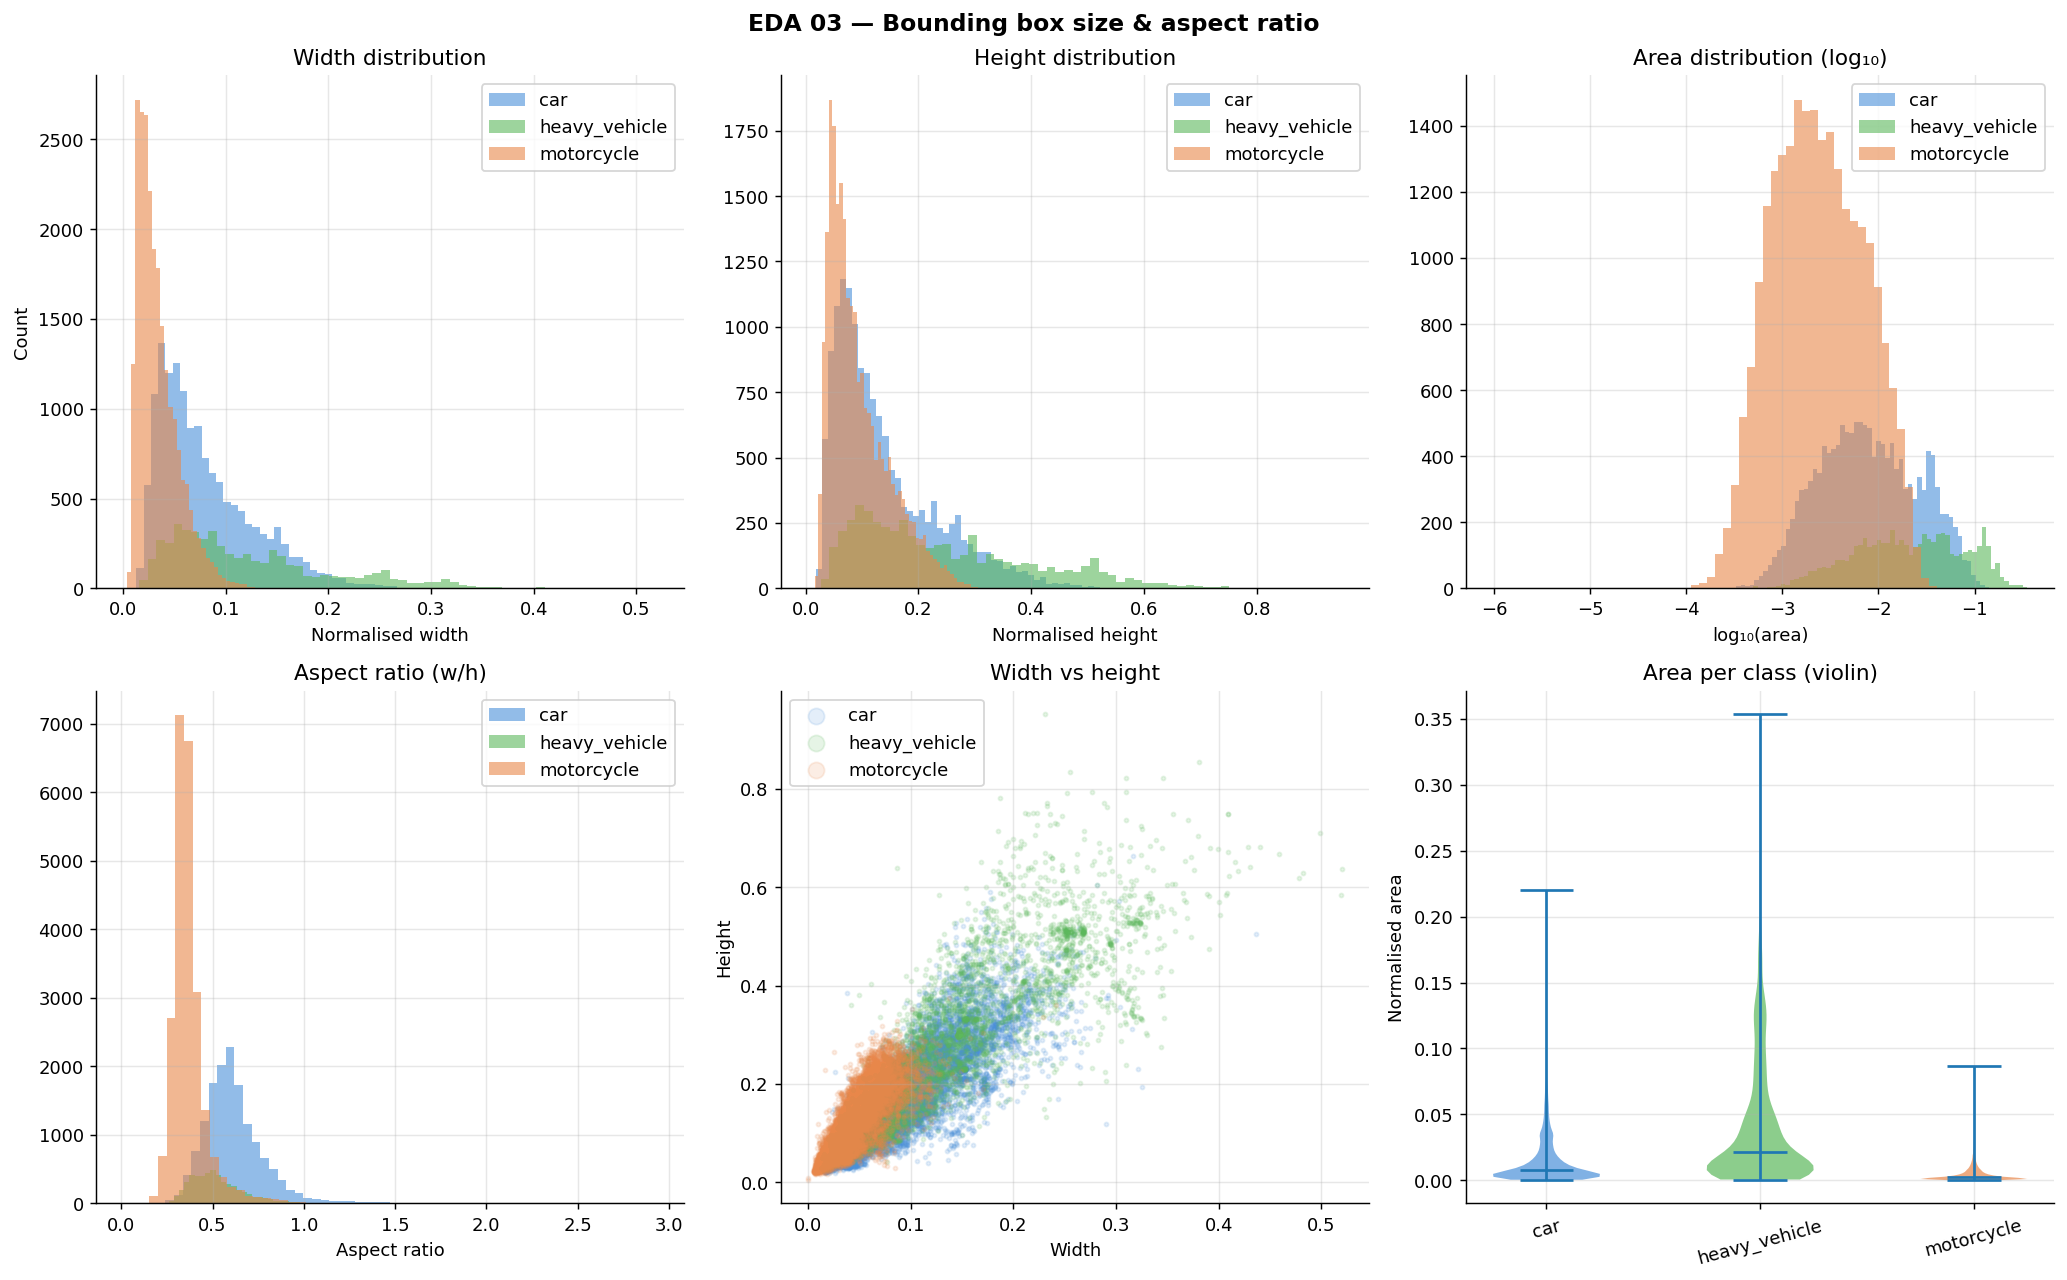

✓ Saved → EDA Results/3. Bounding Box Size.png


In [50]:
valid = data[data["class_name"].notna() & data["bw"].notna()]

for cls in Classes:
    sub = valid[valid["class_name"] == cls]
    if not len(sub): continue
    print(f"  {cls}:")
    print(f"    Width  — mean {sub['bw'].mean():.4f}, median {sub['bw'].median():.4f}, "
          f"range [{sub['bw'].min():.4f}, {sub['bw'].max():.4f}]")
    print(f"    Height — mean {sub['bh'].mean():.4f}, median {sub['bh'].median():.4f}, "
          f"range [{sub['bh'].min():.4f}, {sub['bh'].max():.4f}]")
    print(f"    Area   — mean {sub['area'].mean():.5f}, median {sub['area'].median():.5f}")
    print(f"    Aspect — mean {sub['aspect_ratio'].mean():.2f}, "
          f"median {sub['aspect_ratio'].median():.2f}\n")

tiny = valid[valid["area"] < 0.001]
print(f"Tiny boxes (area < 0.1%): {len(tiny)}  ({len(tiny)/len(valid)*100:.1f}% of all)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA 03 — Bounding box size & aspect ratio", fontweight="bold", fontsize=13)

ax = axes[0,0]
for cls in Classes:
    ax.hist(valid[valid["class_name"]==cls]["bw"], bins=60, alpha=0.6,
            label=cls, color=CLASS_COLORS[cls])
ax.set_title("Width distribution"); ax.set_xlabel("Normalised width")
ax.set_ylabel("Count"); ax.legend()

ax = axes[0,1]
for cls in Classes:
    ax.hist(valid[valid["class_name"]==cls]["bh"], bins=60, alpha=0.6,
            label=cls, color=CLASS_COLORS[cls])
ax.set_title("Height distribution"); ax.set_xlabel("Normalised height"); ax.legend()

ax = axes[0,2]
for cls in Classes:
    sub = valid[valid["class_name"]==cls]["area"].replace(0, np.nan).dropna()
    ax.hist(np.log10(sub), bins=60, alpha=0.6, label=cls, color=CLASS_COLORS[cls])
ax.set_title("Area distribution (log₁₀)"); ax.set_xlabel("log₁₀(area)"); ax.legend()

ax = axes[1,0]
for cls in Classes:
    sub = valid[valid["class_name"]==cls]["aspect_ratio"].dropna()
    ax.hist(sub[sub < 10], bins=60, alpha=0.6, label=cls, color=CLASS_COLORS[cls])
ax.set_title("Aspect ratio (w/h)"); ax.set_xlabel("Aspect ratio"); ax.legend()

ax = axes[1,1]
for cls in Classes:
    sub = valid[valid["class_name"]==cls]
    ax.scatter(sub["bw"], sub["bh"], alpha=0.15, s=5,
               color=CLASS_COLORS[cls], label=cls)
ax.set_title("Width vs height"); ax.set_xlabel("Width"); ax.set_ylabel("Height")
ax.legend(markerscale=4)

ax = axes[1,2]
data_v = [valid[valid["class_name"]==cls]["area"].dropna().values for cls in Classes]
parts  = ax.violinplot(data_v, showmedians=True)
for pc, cls in zip(parts["bodies"], Classes):
    pc.set_facecolor(CLASS_COLORS[cls]); pc.set_alpha(0.7)
ax.set_xticks(range(1, len(Classes)+1))
ax.set_xticklabels(Classes, rotation=15)
ax.set_title("Area per class (violin)"); ax.set_ylabel("Normalised area")

plt.tight_layout()
plt.savefig(f"{OutputDirectory}/3. Bounding Box Size.png", bbox_inches="tight")
plt.show()
print(f"✓ Saved → {OutputDirectory}/3. Bounding Box Size.png")


## 🌫️ EDA 04 — Spatial Distribution

Since CCTV is static, spatial bias can be a great challenge. The model could potentially learn that specific vehicles often goes in a specific lane. AS the result, the model could meemorize the background context (such as lanes, road geometry, and the conrete) rather than the object itself


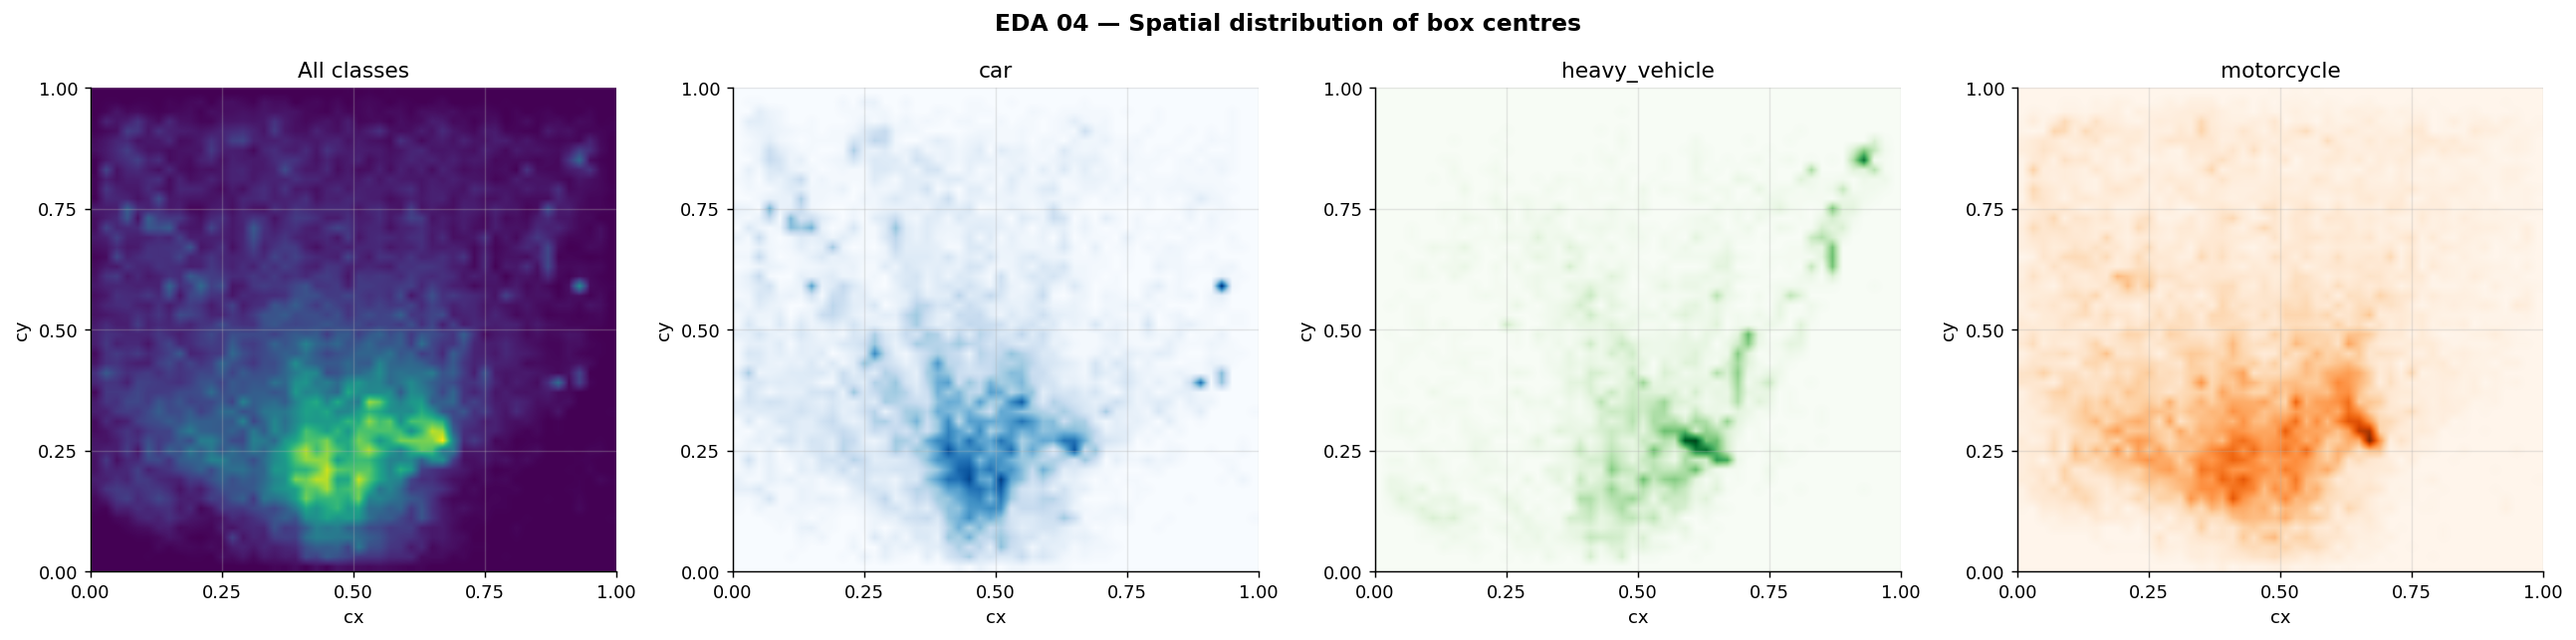

✓ Saved → EDA Results/4. Spatial Distribution.png


In [51]:
valid = data[data["cx"].notna()]

n_cls  = len(Classes)
fig, axes = plt.subplots(1, n_cls+1, figsize=(5*(n_cls+1), 5))
fig.suptitle("EDA 04 — Spatial distribution of box centres",
             fontweight="bold", fontsize=13)

def _heatmap(ax, cx, cy, title, cmap="viridis"):
    h, xe, ye = np.histogram2d(cx, cy, bins=50, range=[[0,1],[0,1]])
    ax.imshow(h.T, origin="lower", extent=[0,1,0,1], aspect="auto", cmap=cmap, interpolation="bilinear")
    ax.set_title(title); ax.set_xlabel("cx"); ax.set_ylabel("cy")
    ax.set_xticks([0,.25,.5,.75,1]); ax.set_yticks([0,.25,.5,.75,1])

_heatmap(axes[0], valid["cx"], valid["cy"], "All classes")
cmaps = {"car":"Blues","motorcycle":"Oranges","heavy_vehicle":"Greens"}
for i, cls in enumerate(Classes):
    sub = valid[valid["class_name"]==cls]
    if len(sub):
        _heatmap(axes[i+1], sub["cx"], sub["cy"], cls, cmaps.get(cls,"hot"))
    else:
        axes[i+1].set_title(f"{cls} (no data)")

plt.tight_layout()
plt.savefig(f"{OutputDirectory}/4. Spatial Distribution.png", bbox_inches="tight")
plt.show()
print(f"✓ Saved → {OutputDirectory}/4. Spatial Distribution.png")

## 🌦️ EDA 05 — Image Brightness & Contrast Quality

Weather plays a crucical role in Computer Vision. It varies Brightness and Contrast qualities such as overexposed scenes, foggy during rain, and dark/low contrast during night

  (Sampling 1000 images for speed)
Mean brightness     : 118.7  (0–255 scale)
Dark (mean < 50)    : 0.0%
Overexposed (>220)  : 0.0%
Low contrast (<20)  : 0.0%


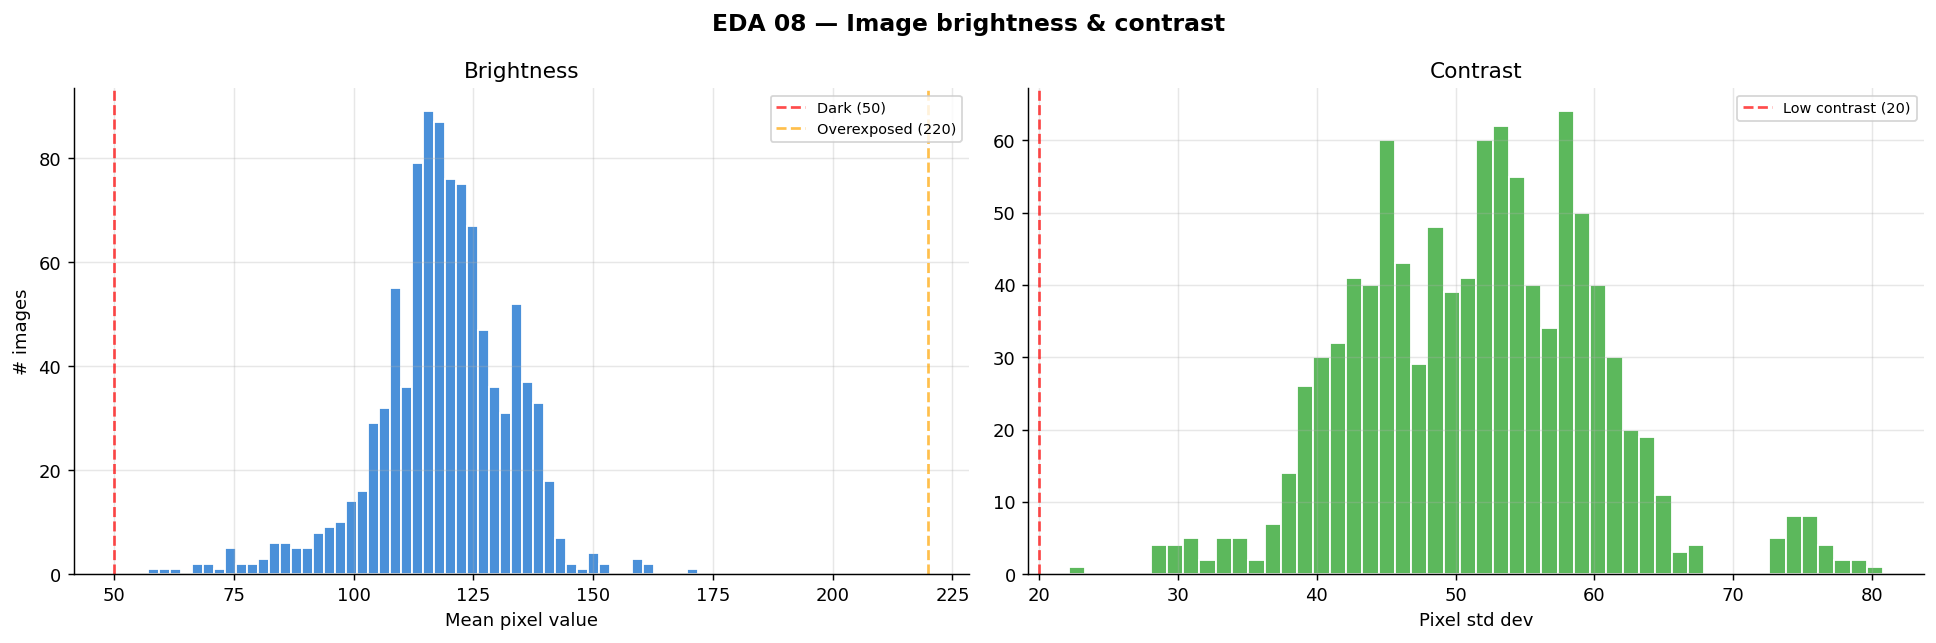

✓ Saved → EDA Results/5. Brightness & Contrast.png


In [ ]:
MAX_IMAGES = 1000

img_data = data[data["img_path"].notna()].drop_duplicates("stem")
if len(img_data) == 0:
    print("  No image paths available.")
else:
    if len(img_data) > MAX_IMAGES:
        img_data = img_data.sample(MAX_IMAGES, random_state=42)
        print(f"  (Sampling {MAX_IMAGES} images for speed)")

    brightness_list, contrast_list, split_list = [], [], []

    for _, row in img_data.iterrows():
        try:
            img  = cv2.imread(row["img_path"])
            if img is None: continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
            brightness_list.append(gray.mean())
            contrast_list.append(gray.std())
            split_list.append(row["split"])
        except Exception:
            continue

    brightness = np.array(brightness_list)
    contrast   = np.array(contrast_list)

    print(f"Mean brightness     : {brightness.mean():.1f}  (0–255 scale)")
    print(f"Dark (mean < 50)    : {(brightness < 50).mean()*100:.1f}%")
    print(f"Overexposed (>220)  : {(brightness > 220).mean()*100:.1f}%")
    print(f"Low contrast (<20)  : {(contrast < 20).mean()*100:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("EDA 08 — Image brightness & contrast", fontweight="bold", fontsize=13)

    ax = axes[0]
    ax.hist(brightness, bins=50, color="#4A90D9", edgecolor="white")
    ax.axvline(50,  color="red",    linestyle="--", alpha=0.7, label="Dark (50)")
    ax.axvline(220, color="orange", linestyle="--", alpha=0.7, label="Overexposed (220)")
    ax.set_title("Brightness"); ax.set_xlabel("Mean pixel value")
    ax.set_ylabel("# images"); ax.legend(fontsize=8)

    ax = axes[1]
    ax.hist(contrast, bins=50, color="#5CB85C", edgecolor="white")
    ax.axvline(20, color="red", linestyle="--", alpha=0.7, label="Low contrast (20)")
    ax.set_title("Contrast"); ax.set_xlabel("Pixel std dev"); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{OutputDirectory}/5. Brightness & Contrast.png", bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {OutputDirectory}/5. Brightness & Contrast.png")


## 🧪 Sample Visualization


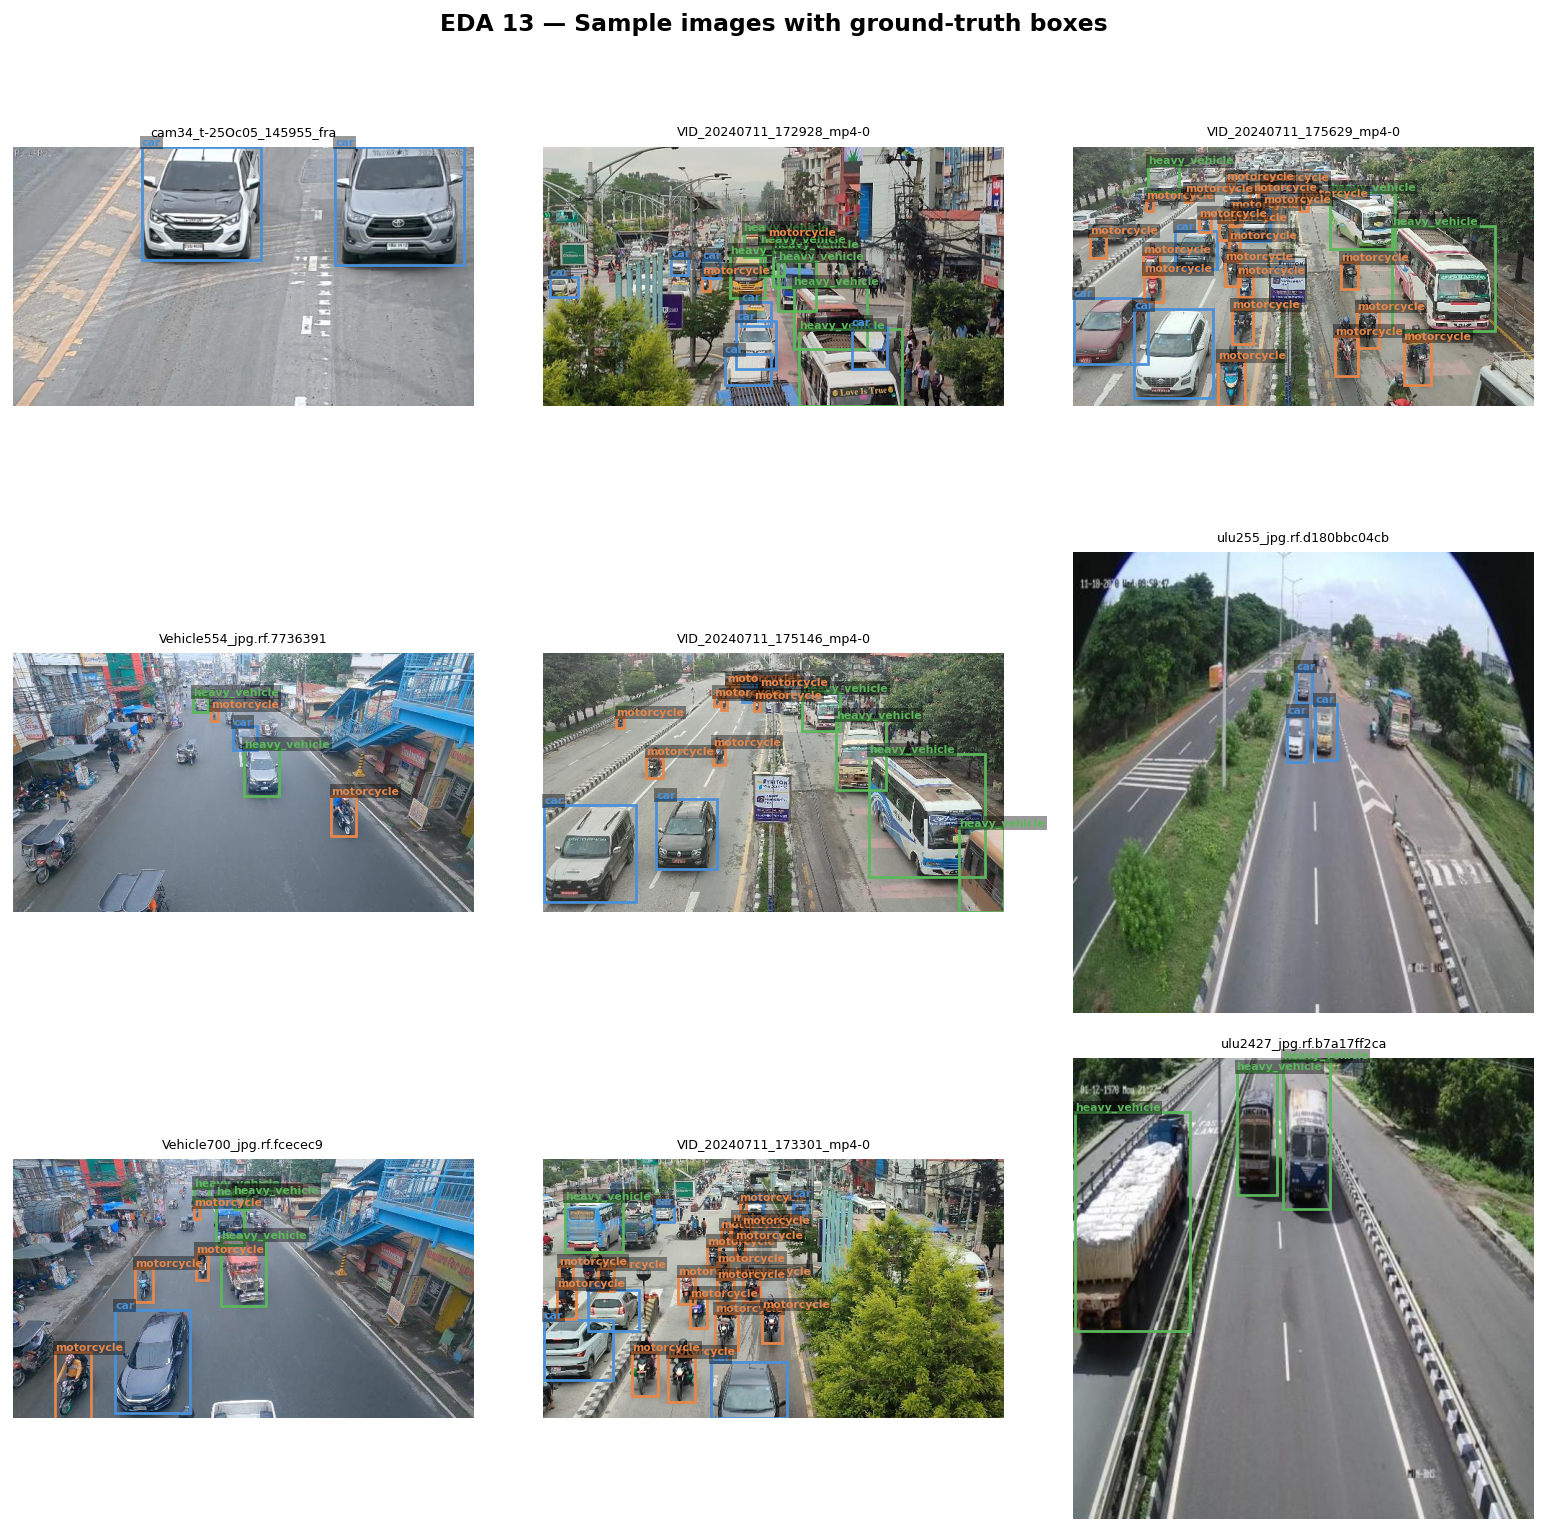

✓ Saved → EDA Results/Sample Visualization.png


In [60]:
# =============================================================================
# EDA 13 — SAMPLE VISUALISATION WITH BOUNDING BOXES
# =============================================================================

N_SAMPLES = 9   # number of images to display

valid_imgs = data[data["img_path"].notna() & data["class_name"].notna()]
stems      = valid_imgs["stem"].unique()

if len(stems) == 0:
    print("  No valid image paths found.")
else:
    sampled = np.random.choice(stems, min(N_SAMPLES, len(stems)), replace=False)
    cols = 3
    rows = int(np.ceil(len(sampled) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    fig.suptitle("EDA 13 — Sample images with ground-truth boxes",
                 fontweight="bold", fontsize=13)
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, stem in zip(axes_flat, sampled):
        ann      = data[data["stem"] == stem]
        img_path = ann["img_path"].dropna().iloc[0] if not ann["img_path"].dropna().empty else None

        if img_path:
            try:
                img_arr = np.array(Image.open(img_path).convert("RGB"))
            except Exception:
                img_arr = np.ones((480,640,3), dtype=np.uint8)*200
        else:
            img_arr = np.ones((480,640,3), dtype=np.uint8)*200

        H, W = img_arr.shape[:2]
        ax.imshow(img_arr)

        for _, row in ann[ann["bw"].notna()].iterrows():
            cx, cy, bw, bh = row["cx"], row["cy"], row["bw"], row["bh"]
            x1 = (cx-bw/2)*W; y1 = (cy-bh/2)*H; w = bw*W; h = bh*H
            color = CLASS_COLORS.get(row["class_name"], "#9E9E9E")
            ax.add_patch(mpatches.FancyBboxPatch(
                (x1,y1), w, h, boxstyle="square,pad=0",
                linewidth=1.5, edgecolor=color, facecolor="none"))
            ax.text(x1, y1-2, row["class_name"], color=color, fontsize=6, fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))

        ax.set_title(stem[:25], fontsize=7); ax.axis("off")

    for ax in axes_flat[len(sampled):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"{OutputDirectory}/Sample Visualization.png", bbox_inches="tight", dpi=120)
    plt.show()
    print(f"✓ Saved → {OutputDirectory}/Sample Visualization.png")
